
# Deep-LDA Collective Variables for Alanine Dipeptide
## A systematic benchmark: CV choice (Deep-LDA / $\phi$ / $\psi$ / $\phi,\psi$) $\times$ bias method (MetaD / WT-MetaD / OPES)

**Author:** Daniele Barbaro — University of Genoa, Department of Physics

This notebook extends `08_deeplda_vs_phi_pipeline.ipynb` with a **full comparison
matrix**, in the spirit of the didactic alanine-dipeptide benchmark of

> L. Bonati, G. Piccini, M. Parrinello, *Deep learning the slow modes for rare events
> sampling*, PNAS **118**, e2113533118 (2021).

**Important methodological note.** The above paper's main contribution is the
**Deep-TICA** CV, built from the variational approach to conformational dynamics (VAC)
applied to *biased* trajectories. **This notebook does not implement Deep-TICA/VAC.**
We keep the state-classification **Deep-LDA** CV of the previous notebooks (Bonati,
Rizzi & Parrinello, *JPCL* 2020) and instead borrow three purely *methodological* ideas
from the 2021 paper:

1. **Deliberately challenging the method with a bad CV.** Just as the paper uses $\psi$
   ("a very poor CV, being almost perpendicular to the direction of the most likely
   transition paths") as a stress test, we bias $\psi$ alone here and quantify how badly
   it performs relative to $\phi$ and to Deep-LDA.
2. **Comparing bias methods on equal footing.** The paper motivates OPES over
   metadynamics because it "reaches the quasistatic regime more rapidly... the bias
   varies more smoothly, and the noise... is reduced." We test this claim directly by
   running **classical (non-tempered) MetaD, Well-Tempered MetaD, and OPES** on the same
   Deep-LDA CV, with matched `PACE`/`SIGMA`.
3. **Counting transitions as a cheap diagnostic.** Sec. "Alanine Dipeptide" of the paper
   reports transition counts/rates as its primary evidence of sampling efficiency
   (e.g. "a 200-fold increase in the number of transitions per unit time"). We use the
   same diagnostic here: for every 5 ns run we count how many times each metastable
   basin is visited.

### What this notebook adds with respect to `08_deeplda_vs_phi_pipeline.ipynb`

- All FES reconstructions and the sensitivity analysis now go exclusively through
  **`mlcolvar.utils.fes.compute_fes`** and **`mlcolvar.explain.sensitivity_analysis`**
  (native N-dimensional KDE with block-averaged error, replacing the hand-rolled 2D KDE
  used previously).
- A **classical (non-well-tempered) MetaD** protocol is added alongside WT-MetaD, and
  analyzed with `plumed sum_hills` (bias inversion), since simple exponential
  reweighting is not rigorously applicable to unbounded-growth metadynamics.
- A **bias on $\psi$ alone** (classical and WT) is added as the "bad CV" control.
- A full **$4~{\rm CVs}\times{\rm methods}$ run matrix** (9 runs total, 5 ns each):

| CV | Classical MetaD | WT-MetaD | OPES |
|---|:---:|:---:|:---:|
| Deep-LDA | ✓ | ✓ | ✓ |
| $\phi$ | ✓ | ✓ | — |
| $\psi$ | ✓ | ✓ | — |
| $\phi,\psi$ (2D) | ✓ | ✓ | — |

- **Basin-visit counting** on all 9 runs (Sec. 6).
- **CV comparison** (Deep-LDA vs. $\phi$ vs. $\psi$ vs. $\phi,\psi$) via FES difference
  maps and RMSE/MAE against a 2D reference (Sec. 8).
- **Bias-method comparison** on Deep-LDA: classical MetaD vs. WT-MetaD vs. OPES (Sec. 9).
- **Classical vs. Well-Tempered** synthesis across all CVs (Sec. 10).

> **Practical note**, as before: GROMACS/PLUMED commands are printed for execution in
> WSL; all analysis cells are self-contained Python to be run once the output files
> exist in `data3/4_matrix/<run_name>/`.


## 0. Setup

In [1]:

import os
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain import sensitivity_analysis
import mlcolvar.utils.plot
import plumed

torch.set_float32_matmul_precision('high')
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Accelerator: {accelerator}")


Accelerator: gpu


In [31]:

# ------------------------------- Configuration -------------------------------
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data3"
GMX_CMD     = "gmx_mpi"

# Unbiased sampling (state characterization + training set)
SAMPLE_STEPS  = 1_000_000     # 2 ns @ dt = 2 fs
SAMPLE_STRIDE = 100

# Biased production runs: ALL 5 ns, matched PACE/HEIGHT/SIGMA across CVs/methods
STRIDE_BIAS   = 100
NUM_STEPS_5NS = 2_500_000     # 5 ns @ dt = 2 fs
PACE          = 500           # 1 hill/kernel deposited every 1 ps -> 5000 depositions/run
HEIGHT        = 1.25          # kJ/mol (MetaD, WT-MetaD)
# BIASFACTOR    = 6.00          # WT-MetaD only
BIASFACTOR    = 10.00
OPES_BARRIER  = 40.0          # kJ/mol, from the barrier estimated in the previous notebook
TEMP          = 300.0
KBT           = 2.494339      # kJ/mol @ 300 K

SIGMA_PHI     = 0.025         # rad
SIGMA_PSI     = 0.025         # rad, deliberately the SAME protocol as phi (fair "bad CV" test)

DESCRIPTORS = "d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19"

os.chdir(BASE_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data directory:", DATA_DIR)


Data directory: /home/dani/wslcoding/MCFM/ML-CV/data3


In [3]:

# ------------------------------- Helper functions -------------------------------

def clean(folder='./'):
    """Remove backup files from `folder` (does NOT remove COLVAR/HILLS)."""
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

def execute(command, folder, background=False):
    """Run a shell command in `folder`, printing stderr on failure."""
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output=True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

def augment_periodic_1d(cv, weights=None, bandwidth=0.05, period=2 * np.pi):
    """Mirror points across the (-pi, pi) periodic boundary before KDE."""
    cv = np.asarray(cv, dtype=float)
    w = None if weights is None else np.asarray(weights, dtype=float)
    margin = 6 * bandwidth
    tiles, tw = [], []
    for shift in (-period, 0, period):
        shifted = cv + shift
        mask = (shifted > -np.pi - margin) & (shifted < np.pi + margin)
        tiles.append(shifted[mask])
        tw.append((w if w is not None else np.ones_like(cv))[mask])
    cv_aug = np.concatenate(tiles)
    w_aug = np.concatenate(tw) if w is not None else None
    return cv_aug, w_aug

def augment_periodic_2d(x, y, weights=None, bandwidth=0.1, period=2 * np.pi):
    """Tile (x, y) by +-period in both dimensions before 2D KDE (periodic boundary)."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    w = np.ones_like(x) if weights is None else np.asarray(weights, dtype=float)
    margin = 6 * bandwidth
    tx, ty, tw = [], [], []
    for dx in (-period, 0, period):
        for dy in (-period, 0, period):
            xs, ys = x + dx, y + dy
            mask = ((xs > -np.pi - margin) & (xs < np.pi + margin) &
                    (ys > -np.pi - margin) & (ys < np.pi + margin))
            tx.append(xs[mask]); ty.append(ys[mask]); tw.append(w[mask])
    return np.concatenate(tx), np.concatenate(ty), np.concatenate(tw)

def rbias_weights(colvar, kbt=KBT):
    """Tiwary-Parrinello reweighting for WT-MetaD/OPES: w_i = exp((V(s_i,t_i) - c(t_i))/kT).
    Requires the columns 'metad.bias' and 'metad.rct' in the COLVAR file (CALC_RCT)."""
    rbias = colvar['metad.bias'].values - colvar['metad.rct'].values
    return np.exp(rbias / kbt)

def count_basin_visits(phi_traj, basin_A, basin_B):
    """Count transitions and per-basin visit counts along a phi trajectory.
    A 'visit' is a contiguous stretch of frames assigned to a basin; frames outside
    both basin ranges (transition region) are ignored for the state sequence."""
    state = np.full(len(phi_traj), -1, dtype=int)
    state[(phi_traj >= basin_A[0]) & (phi_traj <= basin_A[1])] = 0
    state[(phi_traj >= basin_B[0]) & (phi_traj <= basin_B[1])] = 1
    visited = state[state != -1]
    if len(visited) == 0:
        return 0, 0, 0
    changes = np.diff(visited) != 0
    entries = np.r_[True, changes]
    n_transitions = int(np.sum(changes))
    visits_A = int(np.sum((visited == 0) & entries))
    visits_B = int(np.sum((visited == 1) & entries))
    return n_transitions, visits_A, visits_B

def sum_hills_fes(folder, kt=KBT, stride=None):
    """Reconstruct F(s) = -V(s, t_final) directly from the deposited hills
    (valid for classical, non-well-tempered MetaD; NOT a reweighted average)."""
    cmd = "plumed sum_hills --hills HILLS --mintozero --outfile fes_classical.dat"
    if stride is not None:
        cmd += f" --stride {stride}"
    execute(cmd, folder=folder)
    return load_dataframe(str(Path(folder) / "fes_classical.dat"))


## 1. Unbiased sampling of the two metastable states

In [4]:

folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

In [ ]:


Path(folderA).mkdir(parents=True, exist_ok=True)
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderA)
execute(f"cp {MD_IN_DIR}/input.tpr .", folderA)

Path(folderB).mkdir(parents=True, exist_ok=True)
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderB)
execute(f"cp {MD_IN_DIR}/input.sB.tpr input.tpr", folderB)


In [ ]:

plumed_unbiased = f"""\
# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY

INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

PRINT FMT=%g STRIDE={SAMPLE_STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
"""

for f in (folderA, folderB):
    with open(f / "plumed.dat", "w") as fh:
        fh.write(plumed_unbiased)

for f in (folderA, folderB):
    print(f"cd {f}")
    print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps {SAMPLE_STEPS} -v")
    print()


**Run the two commands above in WSL, then continue.**

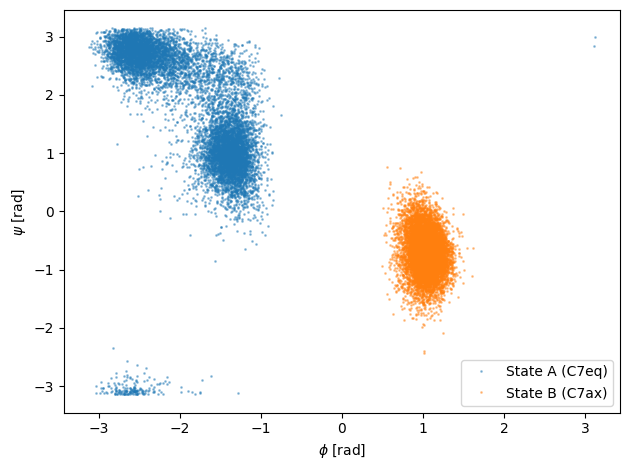

Basin A (C7eq) in phi: (-2.89207, -1.02956)
Basin B (C7ax) in phi: (0.678178, 1.34283)
sigma(phi) State A: 0.5675 rad
sigma(phi) State B: 0.1372 rad


In [5]:

dataA = load_dataframe(f"{folderA}/COLVAR")
dataB = load_dataframe(f"{folderB}/COLVAR")

fig, ax = plt.subplots()
ax.plot(dataA["phi"], dataA["psi"], 'o', alpha=0.4, ms=1, label="State A (C7eq)")
ax.plot(dataB["phi"], dataB["psi"], 'o', alpha=0.4, ms=1, label="State B (C7ax)")
ax.set_xlabel(r"$\phi$ [rad]"); ax.set_ylabel(r"$\psi$ [rad]"); ax.legend()
plt.tight_layout(); plt.show()

# Basin ranges along phi, used later for basin-visit counting on ALL runs
# (phi/psi are printed in every biased simulation regardless of which CV is biased)
PHI_BASIN_A = (float(dataA["phi"].quantile(0.01)), float(dataA["phi"].quantile(0.99)))
PHI_BASIN_B = (float(dataB["phi"].quantile(0.01)), float(dataB["phi"].quantile(0.99)))
print(f"Basin A (C7eq) in phi: {PHI_BASIN_A}")
print(f"Basin B (C7ax) in phi: {PHI_BASIN_B}")

for label, data in [("A", dataA), ("B", dataB)]:
    print(f"sigma(phi) State {label}: {np.std(data['phi']):.4f} rad")


## 2. Deep-LDA collective variable

Training set: 45 pairwise heavy-atom distances, labeled by metastable state.
Architecture `[45, 30, 30, 5]`, `tanh` activations, final linear-discriminant layer
(Bonati, Rizzi & Parrinello, *JPCL* **11**, 2998 (2020)).


In [7]:

filenames = [f"{folderA}/COLVAR", f"{folderB}/COLVAR"]
n_states = len(filenames)

dataset, colvar = create_dataset_from_files(
    filenames,
    filter_args={'regex': 'd_'},
    create_labels=True,
    return_dataframe=True,
)
datamodule = DictModule(dataset, lengths=[0.8, 0.2])
descriptors_names = colvar.filter(regex='d_').columns.values
print(f"Number of descriptors: {len(descriptors_names)}, dataset size: {dataset['data'].shape[0]}")


Class 0 dataframe shape:  (10001, 51)
Class 1 dataframe shape:  (10001, 51)

 - Loaded dataframe (20002, 51): ['time', 'phi', 'psi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (20002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16',

In [15]:

#------------- PARAMETERS -------------
n_input      = dataset['data'].shape[-1]
nodes        = [n_input, 30, 30, 5]
activation   = 'tanh'

lrate        = 0.001
sw_reg       = 0.05
l2_reg       = 1e-5

num_epochs   = 1000
es_patience  = 50
es_min_delta = 0.1
#--------------------------------------

nn_args = {'activation': activation}
options = {'nn': nn_args}

model = DeepLDA(nodes, n_states=n_states, options=options)
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}
model.sw_reg = sw_reg
model


DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

In [16]:
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=es_min_delta,
                                patience=es_patience, mode="min")
tqdm_progress_bar = TQDMProgressBar(refresh_rate=50)

trainer = lightning.Trainer(callbacks=[metrics, early_stopping, tqdm_progress_bar],
                             max_epochs=num_epochs, logger=None, enable_checkpointing=False,
                             accelerator=accelerator, enable_progress_bar=True,
                             enable_model_summary=True)
trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.5 K │ train │ 4.8 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.8 K

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

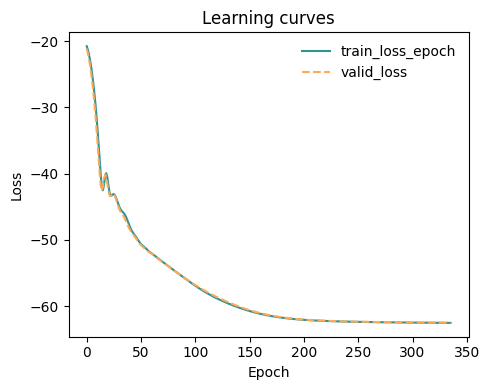

In [17]:



ax = plot_metrics(metrics.metrics, keys=['train_loss_epoch', 'valid_loss'],
                   linestyles=['-', '--'], colors=['fessa1', 'fessa5'], yscale='linear')
plt.tight_layout(); plt.show()


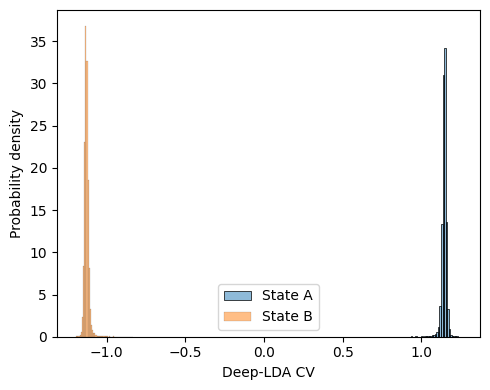

In [18]:

model.eval()
with torch.no_grad():
    s_train = model(dataset['data']).numpy()

labels = dataset['labels'].numpy().flatten()
fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
for st, name in [(0, "State A"), (1, "State B")]:
    sns.histplot(s_train[labels == st, 0], bins=50, stat='density', alpha=0.5, label=name, ax=ax)
ax.set_xlabel("Deep-LDA CV"); ax.set_ylabel("Probability density"); ax.legend()
plt.tight_layout(); plt.show()


## 3. Sensitivity analysis (mlcolvar) and model export

### 3.1 Intra-basin CV fluctuation (correct `SIGMA` estimate)

The metadynamics `SIGMA` must be estimated from the **intra-basin** standard deviation
of the CV, not from the (bimodal) full-dataset standard deviation, which grossly
overestimates the width.


In [19]:

sigma_per_state = {}
for st, name in [(0, "State A"), (1, "State B")]:
    sigma_per_state[st] = float(np.std(s_train[labels == st, 0]))
    print(f"{name}: sigma = {sigma_per_state[st]:.4f}")

sigma_intra = float(np.mean(list(sigma_per_state.values())))
sigma_naive = float(np.std(s_train[:, 0]))
print(f"\nIntra-basin sigma (correct):  {sigma_intra:.4f}")
print(f"Naive full-dataset sigma (WRONG, overestimated): {sigma_naive:.4f}")

SIGMA_DEEPLDA = round(sigma_intra, 3)
print(f"\nSIGMA_DEEPLDA used for all Deep-LDA-biased runs: {SIGMA_DEEPLDA}")


State A: sigma = 0.0175
State B: sigma = 0.0164

Intra-basin sigma (correct):  0.0170
Naive full-dataset sigma (WRONG, overestimated): 1.1356

SIGMA_DEEPLDA used for all Deep-LDA-biased runs: 0.017


### 3.2 Feature relevance

$$ r_i = \sum_{j=1}^n \left| \frac{\partial s^{(j)}}{\partial d_i^{(j)}} \right| \sigma(d_i) $$

computed with `mlcolvar.explain.sensitivity_analysis`.


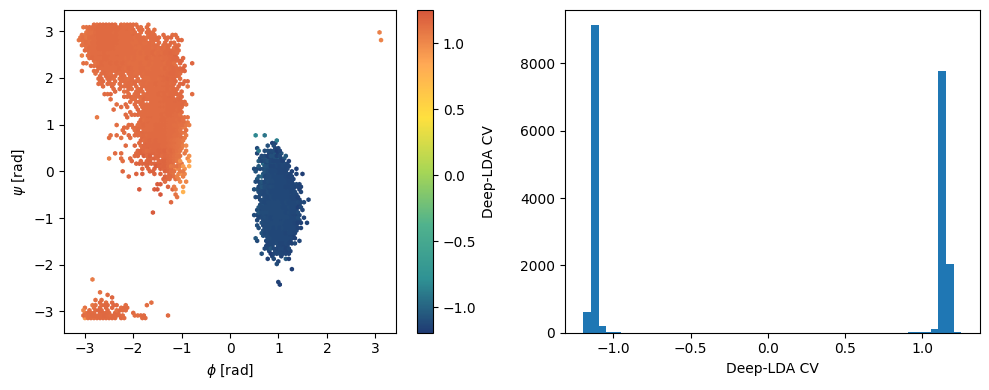

In [20]:

def plot_ramachandran(x, y, z, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.), dpi=100)
        ax.set_title('Ramachandran plot')
    h = ax.hexbin(x, y, C=z, cmap='fessa')
    cbar = plt.colorbar(h, ax=ax); cbar.set_label('Deep-LDA CV')
    ax.set_xlabel(r'$\phi$ [rad]'); ax.set_ylabel(r'$\psi$ [rad]')

def plot_cv_histogram(s, label=None, ax=None, **kwargs):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.), dpi=100)
        ax.set_title('Histogram')
    if isinstance(s, torch.Tensor):
        s = s.squeeze(1).detach().numpy()
    ax.hist(s, **kwargs)
    if label is not None:
        ax.set_xlabel(label)

X_dist = colvar.filter(like='d_', axis=1)
X = torch.tensor(X_dist.values, dtype=torch.float32)

with torch.no_grad():
    s_all = model(X)

_, axs = plt.subplots(1, 2, figsize=(10, 4.), dpi=100)
plot_ramachandran(colvar['phi'], colvar['psi'], s_all, ax=axs[0])
plot_cv_histogram(s_all, label="Deep-LDA CV", bins=50, ax=axs[1])
plt.tight_layout(); plt.show()


KEY:  data


KEY:  labels




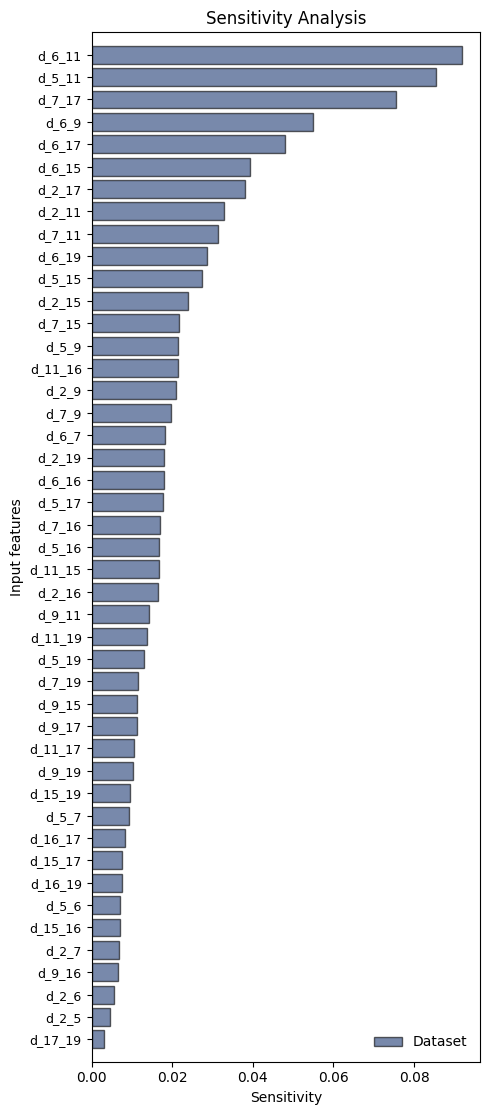

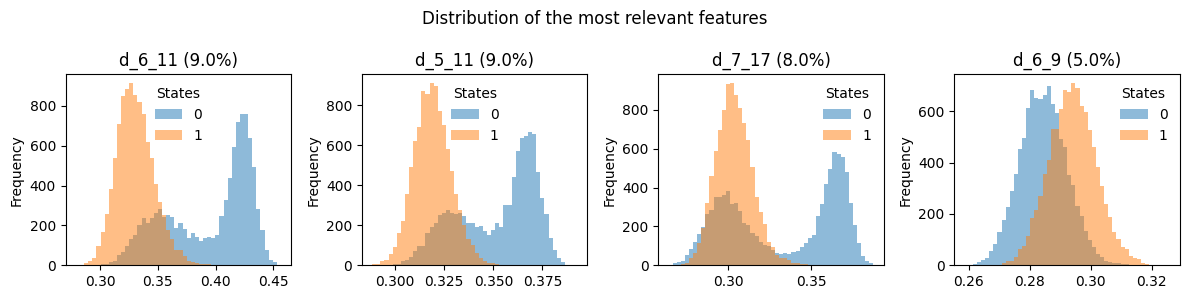

In [21]:

results_sens = sensitivity_analysis(model, dataset, feature_names=dataset.feature_names,
                                     per_class=False, plot_mode='barh')
plt.tight_layout(); plt.show()

plot_n_features = 4
names = results_sens['feature_names'][-plot_n_features:]
sensitivities = results_sens['sensitivity']['Dataset'][-plot_n_features:]

fig, axs = plt.subplots(1, plot_n_features, figsize=(3 * plot_n_features, 3))
plt.suptitle('Distribution of the most relevant features')
for ax, name, sens in zip(axs.flatten()[::-1], names, sensitivities):
    colvar.pivot(columns='labels')[name].plot.hist(bins=50, alpha=0.5, ax=ax)
    ax.set_title(f'{name} ({np.round(sens * 100)}%)')
    ax.legend(title='States', frameon=False)
plt.tight_layout(); plt.show()


### 3.3 Export the trained model to TorchScript for use in PLUMED

In [22]:

folder_ml = DATA_DIR / "1_meta-deeplda/"
Path(folder_ml).mkdir(parents=True, exist_ok=True)

model.eval()
model.to_torchscript(str(folder_ml / "model.ptc"), method="trace")
print("Model exported to", folder_ml / "model.ptc")


Model exported to /home/dani/wslcoding/MCFM/ML-CV/data3/1_meta-deeplda/model.ptc


/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/core/module.py:1549: `LightningModule.to_torchscript` has been deprecated in v2.7 and will be removed in v2.8. TorchScript is deprecated in PyTorch. Use `torch.export.export()` for model exporting instead. See https://pytorch.org/docs/stable/export.html for more information.


## 4. The CV $\times$ bias-method run matrix

All 9 runs share the same `PACE`, `HEIGHT` (for MetaD/WT-MetaD), `TEMP`, and per-CV
`SIGMA`; only the bias method and/or biased CV(s) change, so that any difference in
outcome can be attributed to the CV/method choice rather than to inconsistent tuning.

| name | CV(s) biased | method |
|---|---|---|
| `deeplda_metad` | Deep-LDA | classical MetaD |
| `deeplda_wtmetad` | Deep-LDA | WT-MetaD |
| `deeplda_opes` | Deep-LDA | OPES |
| `phi_metad` | $\phi$ | classical MetaD |
| `phi_wtmetad` | $\phi$ | WT-MetaD |
| `psi_metad` | $\psi$ (bad CV) | classical MetaD |
| `psi_wtmetad` | $\psi$ (bad CV) | WT-MetaD |
| `phipsi_metad` | $\phi,\psi$ (2D) | classical MetaD |
| `phipsi_wtmetad` | $\phi,\psi$ (2D) | WT-MetaD (reference) |

`phipsi_wtmetad` is used later (Sec. 8) as the reference FES, since biasing both
torsions jointly with WT-MetaD is expected to give the most reliable reweighted
estimate of $F(\phi,\psi)$ among the 5 ns runs.


In [32]:
SIGMA_DEEPLDA = 0.05
SIGMA_PHI = 0.05
SIGMA_PSI = 0.05

In [33]:

RUN_MATRIX = [
    ("deeplda_metad",   "deeplda", "MetaD"),
    ("deeplda_wtmetad", "deeplda", "WT-MetaD"),
    ("deeplda_opes",    "deeplda", "OPES"),
    ("phi_metad",       "phi",     "MetaD"),
    ("phi_wtmetad",     "phi",     "WT-MetaD"),
    ("psi_metad",       "psi",     "MetaD"),
    ("psi_wtmetad",     "psi",     "WT-MetaD"),
    ("phipsi_metad",    "phi,psi", "MetaD"),
    ("phipsi_wtmetad",  "phi,psi", "WT-MetaD"),
]

CV_SPECS = {
    "deeplda":  dict(arg="deep.node-0", gmin="-2",     gmax="2",   gbin="750",
                      extra_header=f"\nINCLUDE FILE={INPUT_DIR}/plumed-distances.dat\ndeep: PYTORCH_MODEL FILE=model.ptc ARG={DESCRIPTORS}\n"),
    "phi":      dict(arg="phi",         gmin="-pi",    gmax="pi",  gbin="750", extra_header=""),
    "psi":      dict(arg="psi",         gmin="-pi",    gmax="pi",  gbin="750", extra_header=""),
    "phi,psi":  dict(arg="phi,psi",     gmin="-pi,-pi", gmax="pi,pi", gbin="300,300", extra_header=""),
}

SIGMA_MAP = {
    "deeplda": None,  # filled below, after SIGMA_DEEPLDA is available (Sec. 3.1)
    "phi": str(SIGMA_PHI),
    "psi": str(SIGMA_PSI),
    "phi,psi": f"{SIGMA_PHI},{SIGMA_PSI}",
}
SIGMA_MAP["deeplda"] = str(SIGMA_DEEPLDA)


In [34]:

def make_plumed(cv, method, barrier=OPES_BARRIER):
    spec = CV_SPECS[cv]
    arg, sigma = spec["arg"], SIGMA_MAP[cv]

    header = f"""# vim:ft=plumed
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
ene: ENERGY
{spec['extra_header']}"""

    if method == "MetaD":
        bias = f"""
metad: METAD ARG={arg} ...
   PACE={PACE} HEIGHT={HEIGHT} TEMP={TEMP}
   SIGMA={sigma}
   FILE=HILLS GRID_MIN={spec['gmin']} GRID_MAX={spec['gmax']} GRID_BIN={spec['gbin']}
...
"""
    elif method == "WT-MetaD":
        bias = f"""
metad: METAD ARG={arg} ...
   PACE={PACE} HEIGHT={HEIGHT} BIASFACTOR={BIASFACTOR} TEMP={TEMP}
   SIGMA={sigma}
   FILE=HILLS GRID_MIN={spec['gmin']} GRID_MAX={spec['gmax']} GRID_BIN={spec['gbin']} CALC_RCT
...
"""
    elif method == "OPES":
        bias = f"""
metad: OPES_METAD ARG={arg} ...
   PACE={PACE} SIGMA={sigma} BARRIER={barrier} TEMP={TEMP}
   FILE=KERNELS
...
"""
    else:
        raise ValueError(method)

    print_args = ["phi", "psi"]
    for a in arg.split(","):
        if a not in print_args:
            print_args.append(a)
    print_args.append("metad.bias")
    if method in ("WT-MetaD", "OPES"):
        print_args.append("metad.rct")

    footer = f"\nPRINT FMT=%g STRIDE={STRIDE_BIAS} FILE=COLVAR ARG={','.join(print_args)}\nENDPLUMED\n"
    return header + bias + footer


def prepare_run(name, cv, method):
    folder = DATA_DIR / "4_matrix" / name
    Path(folder).mkdir(parents=True, exist_ok=True)
    execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder)
    execute(f"cp {MD_IN_DIR}/input.tpr .", folder)
    if cv == "deeplda":
        execute(f"cp {folder_ml}/model.ptc .", folder)

    with open(folder / "plumed.dat", "w") as f:
        f.write(make_plumed(cv, method))

    print(f"cd {folder}")
    print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps {NUM_STEPS_5NS} -v")
    print()
    return folder


run_folders = {}
for name, cv, method in RUN_MATRIX:
    run_folders[name] = prepare_run(name, cv, method)


Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data3/1_meta-deeplda/model.ptc .
cd /home/dani/wslcoding/MCFM/ML-CV/data3/4_matrix/deeplda_metad
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 2500000 -v

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data3/1_meta-deeplda/model.ptc .
cd /home/dani/wslcoding/MCFM/ML-CV/data3/4_matrix/deeplda_wtmetad
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -pin on -nsteps 2500000 -v

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data3/1_m

**Run the nine commands above in WSL (independent, can be parallelized/queued),
then continue with the analysis below.**

> Restart tip: `gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -cpi alanine.cpt -append -ntomp 1 -nsteps <N> -v`


## 5. Load all runs

In [36]:

RUN_INFO = {name: (cv, method) for name, cv, method in RUN_MATRIX}
colvars = {name: load_dataframe(str(folder / "COLVAR")) for name, folder in run_folders.items()}

for name, df in colvars.items():
    cv, method = RUN_INFO[name]
    print(f"{name:20s} CV={cv:10s} method={method:10s} n_frames={len(df)}")


deeplda_metad        CV=deeplda    method=MetaD      n_frames=24601
deeplda_wtmetad      CV=deeplda    method=WT-MetaD   n_frames=25001
deeplda_opes         CV=deeplda    method=OPES       n_frames=25001
phi_metad            CV=phi        method=MetaD      n_frames=25001
phi_wtmetad          CV=phi        method=WT-MetaD   n_frames=25001
psi_metad            CV=psi        method=MetaD      n_frames=25001
psi_wtmetad          CV=psi        method=WT-MetaD   n_frames=25001
phipsi_metad         CV=phi,psi    method=MetaD      n_frames=25001
phipsi_wtmetad       CV=phi,psi    method=WT-MetaD   n_frames=25001


## 6. Basin-exploration statistics over 5 ns

Since $\phi$ and $\psi$ are printed in **every** run regardless of which CV is biased,
basin membership can be assessed consistently across the whole matrix using the $\phi$
ranges estimated from the unbiased runs (Sec. 1). This mirrors the diagnostic used by
Bonati, Piccini & Parrinello (PNAS 2021) to quantify sampling efficiency (number of
inter-state transitions per unit time).


In [37]:

rows = []
for name, (cv, method) in RUN_INFO.items():
    phi_traj = colvars[name]["phi"].values
    n_trans, visits_A, visits_B = count_basin_visits(phi_traj, PHI_BASIN_A, PHI_BASIN_B)
    rows.append(dict(run=name, CV=cv, method=method,
                      n_transitions=n_trans, visits_A=visits_A, visits_B=visits_B,
                      transitions_per_ns=n_trans / 5.0))

basin_stats = pd.DataFrame(rows).sort_values(["CV", "method"]).reset_index(drop=True)
basin_stats


,run,CV,method,n_transitions,visits_A,visits_B,transitions_per_ns
0,deeplda_metad,deeplda,MetaD,68,35,34,13.6
1,deeplda_opes,deeplda,OPES,30,16,15,6.0
2,deeplda_wtmetad,deeplda,WT-MetaD,57,29,29,11.4
3,phi_metad,phi,MetaD,460,231,230,92.0
4,phi_wtmetad,phi,WT-MetaD,326,164,163,65.2
5,phipsi_metad,"phi,psi",MetaD,1,1,1,0.2
6,phipsi_wtmetad,"phi,psi",WT-MetaD,0,1,0,0.0
7,psi_metad,psi,MetaD,4,3,2,0.8
8,psi_wtmetad,psi,WT-MetaD,2,2,1,0.4


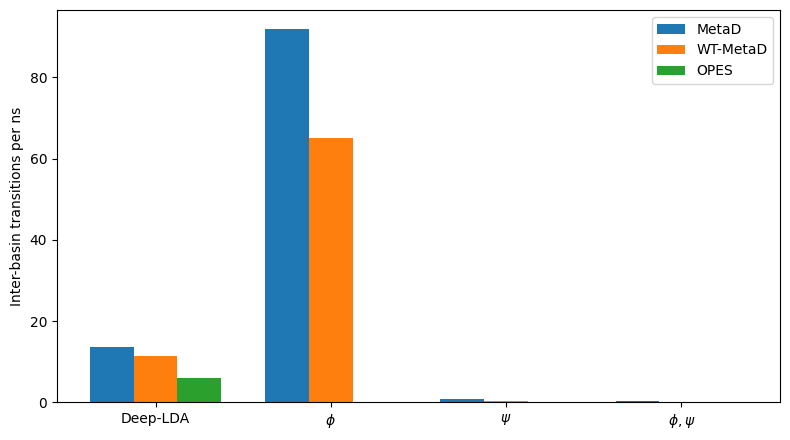

In [38]:

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)
order = ["deeplda", "phi", "psi", "phi,psi"]
methods = ["MetaD", "WT-MetaD", "OPES"]
width = 0.25
x = np.arange(len(order))
for i, method in enumerate(methods):
    vals = [basin_stats.query("CV == @cv and method == @method")["transitions_per_ns"].sum()
            if not basin_stats.query("CV == @cv and method == @method").empty else 0
            for cv in order]
    ax.bar(x + (i - 1) * width, vals, width, label=method)
ax.set_xticks(x); ax.set_xticklabels([r"Deep-LDA", r"$\phi$", r"$\psi$", r"$\phi,\psi$"])
ax.set_ylabel("Inter-basin transitions per ns")
ax.legend(); plt.tight_layout(); plt.show()


## 7. FES reconstruction with `mlcolvar`

### 7.1 Classical MetaD: bias inversion (`plumed sum_hills`)

For **classical, non-well-tempered** MetaD the hill height never decays, so the
quasi-static assumption behind exponential reweighting ($w_i = e^{\beta V(s_i,t_i)}$)
does not hold over the whole trajectory. The standard practical estimate is instead
$$ F(s) \approx -V(s, t_{\rm final}) $$
i.e. a **direct bias inversion**, obtained with `plumed sum_hills`.


Completed: plumed sum_hills --hills HILLS --mintozero --outfile fes_classical.dat
Completed: plumed sum_hills --hills HILLS --mintozero --outfile fes_classical.dat
Completed: plumed sum_hills --hills HILLS --mintozero --outfile fes_classical.dat
Completed: plumed sum_hills --hills HILLS --mintozero --outfile fes_classical.dat


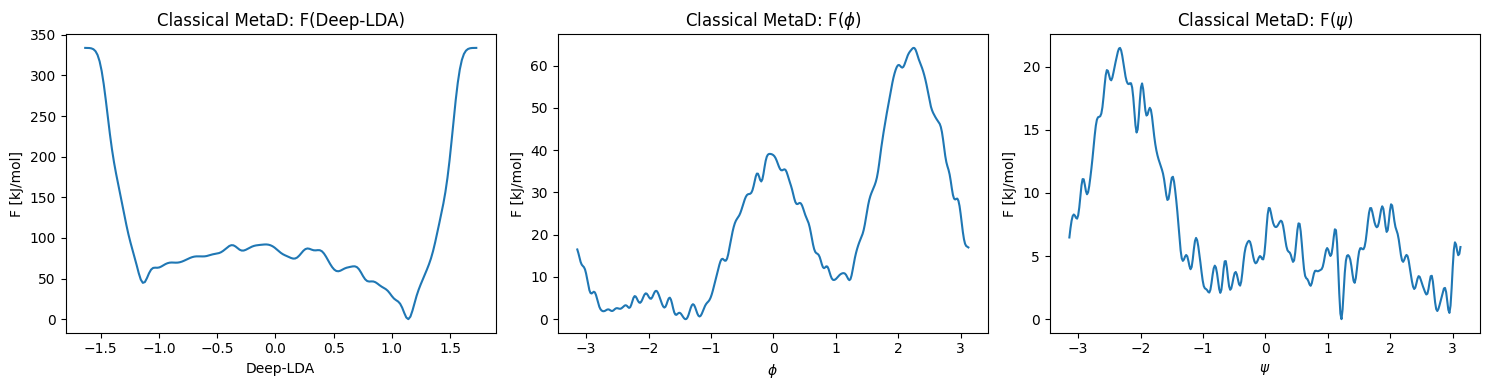

In [39]:

classical_runs = [name for name, (cv, method) in RUN_INFO.items() if method == "MetaD"]

fes_classical = {}
for name in classical_runs:
    fes_classical[name] = sum_hills_fes(run_folders[name])

fig, axs = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
for ax, name, cv_label in zip(axs, ["deeplda_metad", "phi_metad", "psi_metad"],
                               ["Deep-LDA", r"$\phi$", r"$\psi$"]):
    df = fes_classical[name]
    arg_col = df.columns[0]
    ax.plot(df[arg_col], df["file.free"])
    ax.set_xlabel(cv_label); ax.set_ylabel("F [kJ/mol]")
    ax.set_title(f"Classical MetaD: F({cv_label})")
plt.tight_layout(); plt.show()


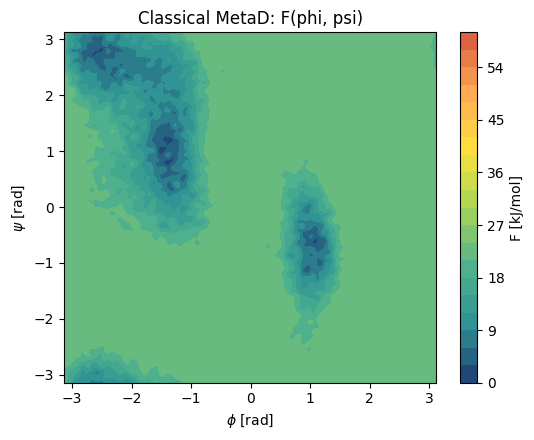

In [40]:

# 2D classical MetaD on (phi, psi): grid file from sum_hills, plotted with tricontourf
df2d = fes_classical["phipsi_metad"]
fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=100)
levels = np.linspace(0, 60, 21)
cs = ax.tricontourf(df2d["phi"], df2d["psi"], np.clip(df2d["file.free"], 0, 60), levels=levels, cmap='fessa')
ax.set_xlabel(r"$\phi$ [rad]"); ax.set_ylabel(r"$\psi$ [rad]")
ax.set_title("Classical MetaD: F(phi, psi)")
fig.colorbar(cs, ax=ax, label="F [kJ/mol]")
plt.tight_layout(); plt.show()


### 7.2 WT-MetaD / OPES: reweighted FES with `mlcolvar.utils.fes.compute_fes`

For these quasi-static bias methods, frames are reweighted with
$w_i = \exp[(V(s_i,t_i) - c(t_i))/k_BT]$ (Tiwary & Parrinello, *JPCB* **119**, 736
(2015); the same formula underlies Eq. 11-12 of Bonati, Piccini & Parrinello, PNAS 2021).
Periodic CVs ($\phi$, $\psi$) are tiled by $\pm 2\pi$ near the boundary before the KDE.


In [41]:

def fes_1d_periodic(cv_values, weights, bandwidth=0.05, num_samples=200, blocks=1):
    cv_aug, w_aug = augment_periodic_1d(cv_values, weights, bandwidth=bandwidth)
    fes, grid, bounds, err = compute_fes(cv_aug, kbt=KBT, bounds=(-np.pi, np.pi),
                                          bandwidth=bandwidth, weights=w_aug,
                                          blocks=blocks, num_samples=num_samples, plot=False, backend="sklearn")
    return grid, fes, err

def fes_1d_deeplda(cv_values, weights, bandwidth=0.03, num_samples=200, blocks=1,
                    bound=1.3):
    fes, grid, bounds, err = compute_fes(cv_values, kbt=KBT, bounds=(-bound, bound),
                                          bandwidth=bandwidth, weights=weights,
                                          blocks=blocks, num_samples=num_samples, plot=False, backend="sklearn")
    return grid, fes, err

def fes_2d_phipsi(phi, psi, weights, bandwidth=0.12, num_samples=100, blocks=1):
    xa, ya, wa = augment_periodic_2d(phi, psi, weights, bandwidth=bandwidth)
    X = np.stack([xa, ya], axis=1)
    fes, grid, bounds, err = compute_fes(X, kbt=KBT, bounds=[(-np.pi, np.pi), (-np.pi, np.pi)],
                                          bandwidth=bandwidth, weights=wa,
                                          blocks=blocks, num_samples=num_samples, plot=False, backend="sklearn")
    return grid, fes, err


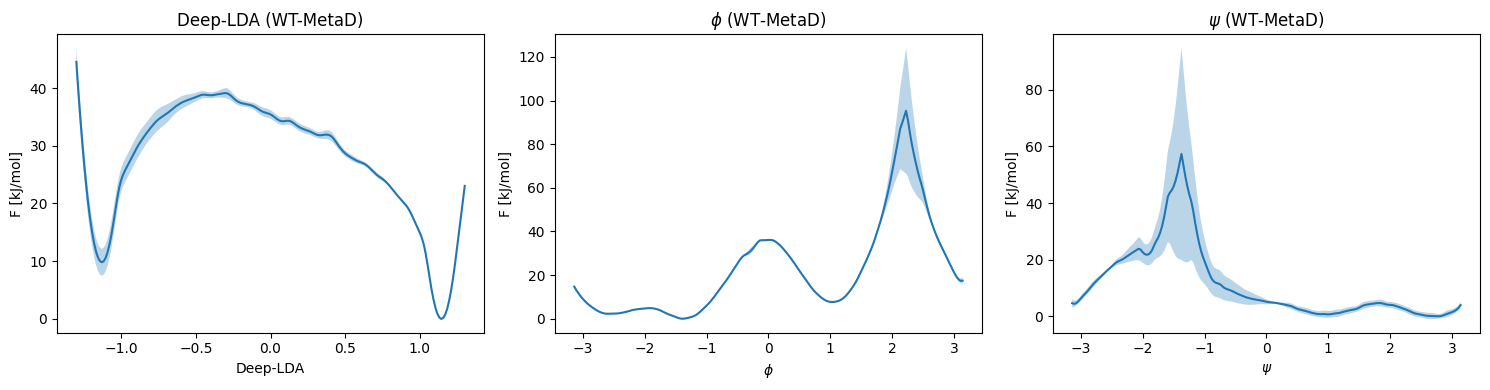

In [42]:

quasistatic_runs = [name for name, (cv, method) in RUN_INFO.items() if method in ("WT-MetaD", "OPES")]
weights = {name: rbias_weights(colvars[name]) for name in quasistatic_runs}

# ---- 1D FES along the biased CV, for each quasistatic run ----
fes_1d = {}
for name in quasistatic_runs:
    cv, method = RUN_INFO[name]
    df, w = colvars[name], weights[name]
    if cv == "deeplda":
        grid, fes, err = fes_1d_deeplda(df["deep.node-0"].values, w, blocks=5)
    elif cv in ("phi", "psi"):
        grid, fes, err = fes_1d_periodic(df[cv].values, w, blocks=5)
    else:
        continue  # phi,psi handled in 2D below
    fes_1d[name] = (grid, fes, err)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
for ax, name, label in zip(axs, ["deeplda_wtmetad", "phi_wtmetad", "psi_wtmetad"],
                            ["Deep-LDA (WT-MetaD)", r"$\phi$ (WT-MetaD)", r"$\psi$ (WT-MetaD)"]):
    grid, fes, err = fes_1d[name]
    ax.plot(grid, fes)
    if err is not None:
        ax.fill_between(grid, fes - err, fes + err, alpha=0.3)
    ax.set_xlabel(label.split(" (")[0]); ax.set_ylabel("F [kJ/mol]"); ax.set_title(label)
plt.tight_layout(); plt.show()


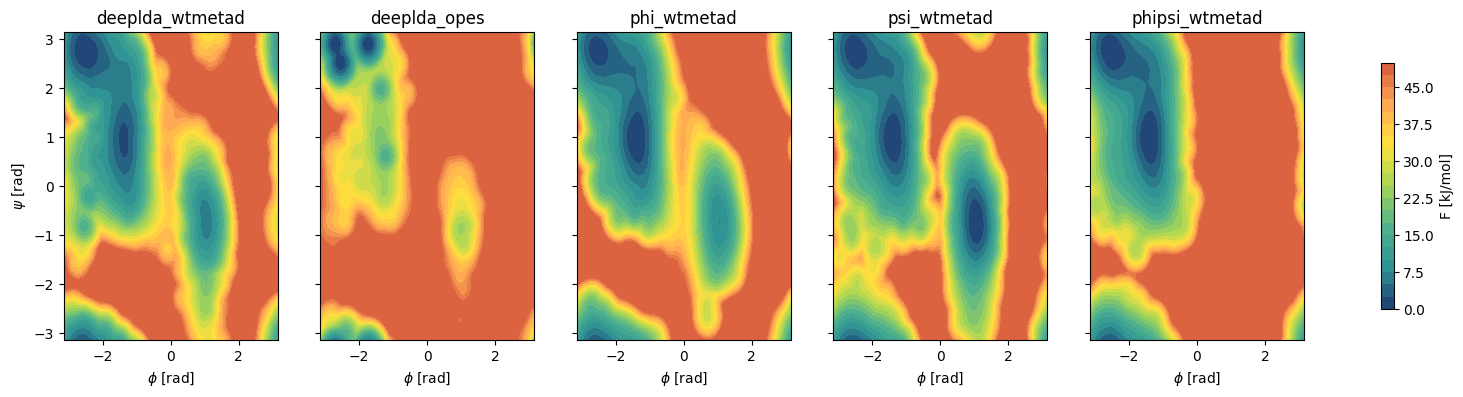

In [43]:

# ---- 2D FES(phi,psi), reweighted, for every quasistatic run ----
fes_2d = {}
for name in quasistatic_runs:
    df, w = colvars[name], weights[name]
    grid, fes, err = fes_2d_phipsi(df["phi"].values, df["psi"].values, w, blocks=1)
    fes_2d[name] = (grid, fes, err)

fig, axs = plt.subplots(1, len(quasistatic_runs), figsize=(4 * len(quasistatic_runs), 4), dpi=100, sharey=True)
FES_CAP = 50.0
for ax, name in zip(axs, quasistatic_runs):
    (X, Y), fes, _ = fes_2d[name]
    cs = ax.contourf(X, Y, np.clip(fes, 0, FES_CAP), levels=20, cmap='fessa')
    ax.set_title(name); ax.set_xlabel(r"$\phi$ [rad]")
axs[0].set_ylabel(r"$\psi$ [rad]")
fig.colorbar(cs, ax=axs, shrink=0.8, label="F [kJ/mol]")
plt.show()


## 8. CV comparison: Deep-LDA vs. $\phi$ vs. $\psi$ vs. $\phi,\psi$

The `phipsi_wtmetad` run (2D bias on both torsions) is taken as the **reference**
$F(\phi,\psi)$. The 1D-biased runs (`deeplda_wtmetad`, `phi_wtmetad`, `psi_wtmetad`),
reweighted onto the same $(\phi,\psi)$ plane, are compared to it via difference maps
$$ \Delta F(\phi,\psi) = F_{\rm CV}(\phi,\psi) - F_{\rm ref}(\phi,\psi) $$
and the aggregate RMSE/MAE (region with $F_{\rm ref} <$ cutoff only, to avoid comparing
noisy, poorly sampled high-energy tails).


In [44]:

def fes_error_metrics(F_test, F_ref, cutoff=30.0):
    mask = F_ref < cutoff
    diff = F_test[mask] - F_ref[mask]
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    return rmse, mae, mask

(Xref, Yref), F_ref, _ = fes_2d["phipsi_wtmetad"]

cv_run_map = {"Deep-LDA": "deeplda_wtmetad", "phi": "phi_wtmetad", "psi": "psi_wtmetad"}
metrics_rows = []
diffs = {}
for label, name in cv_run_map.items():
    (X, Y), F, _ = fes_2d[name]
    rmse, mae, mask = fes_error_metrics(F, F_ref)
    diffs[label] = np.where(mask, F - F_ref, np.nan)
    metrics_rows.append(dict(CV=label, RMSE=rmse, MAE=mae))

cv_comparison = pd.DataFrame(metrics_rows)
cv_comparison


,CV,RMSE,MAE
0,Deep-LDA,6.358706,3.341038
1,phi,7.779809,2.743548
2,psi,2.780990,1.265841


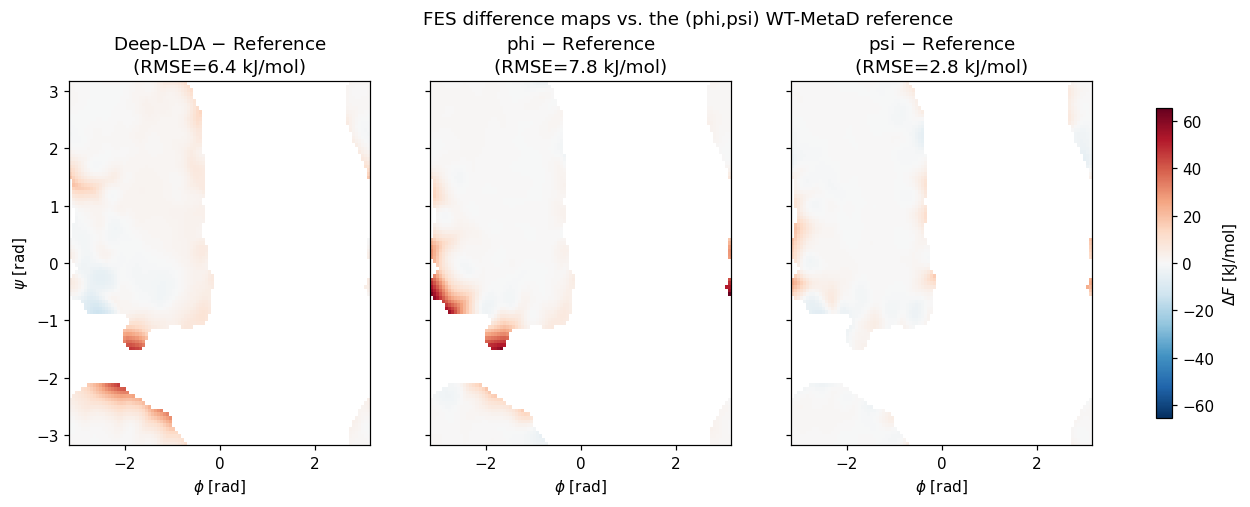

In [45]:

fig, axs = plt.subplots(1, 3, figsize=(15, 4.3), dpi=110, sharex=True, sharey=True)
vmax = np.nanmax(np.abs(np.concatenate([d.ravel() for d in diffs.values()])))
for ax, (label, d) in zip(axs, diffs.items()):
    rmse = cv_comparison.set_index("CV").loc[label, "RMSE"]
    cs = ax.pcolormesh(Xref, Yref, d, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_title(f"{label} $-$ Reference\n(RMSE={rmse:.1f} kJ/mol)")
    ax.set_xlabel(r"$\phi$ [rad]")
axs[0].set_ylabel(r"$\psi$ [rad]")
fig.colorbar(cs, ax=axs, shrink=0.85, label=r"$\Delta F$ [kJ/mol]")
plt.suptitle("FES difference maps vs. the (phi,psi) WT-MetaD reference", y=1.03)
plt.show()


**Expected/typical outcome** (to be checked against the actual runs): $\phi$
should have the lowest RMSE, being close to an ideal 1D CV for this system; $\psi$
should have by far the largest RMSE and the fewest transitions in Sec. 6 (consistent
with it being "almost perpendicular to the direction of the most likely transition
paths", Bonati, Piccini & Parrinello 2021); Deep-LDA, trained blindly on 45 distances
with no angle information, is expected to fall much closer to $\phi$ than to $\psi$.


## 9. Bias-method comparison on Deep-LDA: MetaD vs. WT-MetaD vs. OPES

Following the rationale of Bonati, Piccini & Parrinello (PNAS 2021) for preferring OPES
("it reaches the quasistatic regime more rapidly than metadynamics... the bias varies
more smoothly"), the three methods are compared on **the same CV** (Deep-LDA) and the
same 5 ns budget.


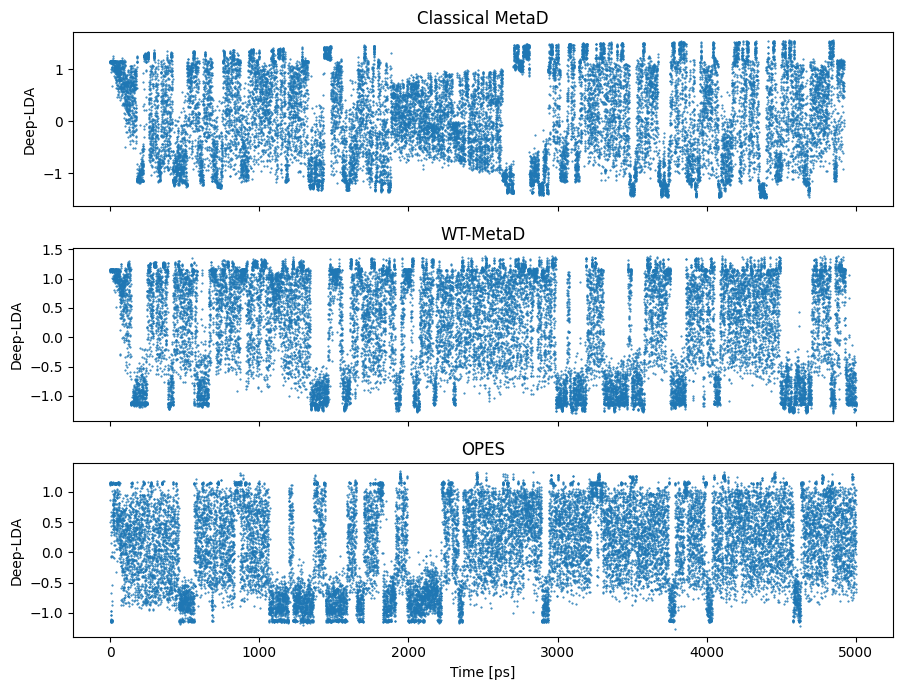

In [46]:

fig, axs = plt.subplots(3, 1, figsize=(9, 7), dpi=100, sharex=True)
for ax, name, title in zip(axs, ["deeplda_metad", "deeplda_wtmetad", "deeplda_opes"],
                            ["Classical MetaD", "WT-MetaD", "OPES"]):
    df = colvars[name]
    ax.plot(df["time"], df["deep.node-0"], '.', ms=1)
    ax.set_ylabel("Deep-LDA"); ax.set_title(title)
axs[-1].set_xlabel("Time [ps]")
plt.tight_layout(); plt.show()


In [47]:

method_stats = basin_stats.query("CV == 'deeplda'")[["method", "n_transitions", "transitions_per_ns"]]
method_stats


,method,n_transitions,transitions_per_ns
0,MetaD,68,13.6
1,OPES,30,6.0
2,WT-MetaD,57,11.4


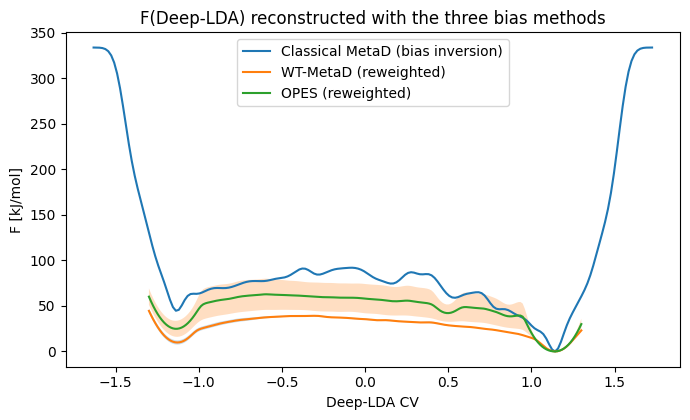

In [48]:

fig, ax = plt.subplots(figsize=(7, 4.3), dpi=100)
grid_mc, fes_mc = fes_classical["deeplda_metad"]["deep.node-0"].values, fes_classical["deeplda_metad"]["file.free"].values
order_mc = np.argsort(grid_mc)
ax.plot(grid_mc[order_mc], fes_mc[order_mc], label="Classical MetaD (bias inversion)")

grid_wt, fes_wt, err_wt = fes_1d["deeplda_wtmetad"]
ax.plot(grid_wt, fes_wt, label="WT-MetaD (reweighted)")
if err_wt is not None:
    ax.fill_between(grid_wt, fes_wt - err_wt, fes_wt + err_wt, alpha=0.25)

grid_op, fes_op, err_op = fes_1d["deeplda_opes"]
ax.plot(grid_op, fes_op, label="OPES (reweighted)")
if err_op is not None:
    ax.fill_between(grid_op, fes_op - err_op, fes_op + err_op, alpha=0.25)

ax.set_xlabel("Deep-LDA CV"); ax.set_ylabel("F [kJ/mol]")
ax.legend(); ax.set_title("F(Deep-LDA) reconstructed with the three bias methods")
plt.tight_layout(); plt.show()


A **narrower spread** of the shaded (block-averaged) error bands and a **higher
`transitions_per_ns`** for OPES relative to (WT-)MetaD, at equal `PACE`/`SIGMA`, would
directly support the paper's stated motivation for preferring OPES.


## 10. Classical vs. Well-Tempered metadynamics, across all CVs

Classical MetaD keeps depositing hills of constant height indefinitely: the bias never
stops growing, so past a certain point the system is pushed away from the region of
interest and sampling efficiency degrades (hence the direct bias-inversion analysis of
Sec. 7.1 instead of reweighting). WT-MetaD tempers the hill height as
$h(t) = H_0 e^{-V(s,t)/[(\gamma-1)k_BT]}$, letting the bias converge to $F(s)/\gamma$,
which both remains bounded and allows proper reweighting.


In [49]:

comparison_rows = []
for cv in ["deeplda", "phi", "psi", "phi,psi"]:
    row = {"CV": cv}
    for method in ["MetaD", "WT-MetaD"]:
        sub = basin_stats.query("CV == @cv and method == @method")
        row[f"{method} transitions/ns"] = float(sub["transitions_per_ns"].iloc[0]) if len(sub) else np.nan
    comparison_rows.append(row)

classical_vs_wt = pd.DataFrame(comparison_rows)
classical_vs_wt


,CV,MetaD transitions/ns,WT-MetaD transitions/ns
0,deeplda,13.6,11.4
1,phi,92.0,65.2
2,psi,0.8,0.4
3,"phi,psi",0.2,0.0


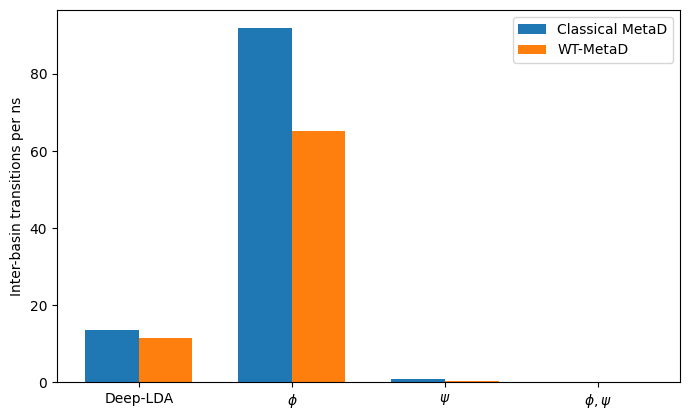

In [50]:

fig, ax = plt.subplots(figsize=(7, 4.3), dpi=100)
x = np.arange(len(classical_vs_wt))
width = 0.35
ax.bar(x - width/2, classical_vs_wt["MetaD transitions/ns"], width, label="Classical MetaD")
ax.bar(x + width/2, classical_vs_wt["WT-MetaD transitions/ns"], width, label="WT-MetaD")
ax.set_xticks(x); ax.set_xticklabels([r"Deep-LDA", r"$\phi$", r"$\psi$", r"$\phi,\psi$"])
ax.set_ylabel("Inter-basin transitions per ns")
ax.legend(); plt.tight_layout(); plt.show()


If classical MetaD shows a comparable or higher transition rate than WT-MetaD
within the first 5 ns, this is expected and not a contradiction: **early on**, before
the bias has filled the underlying well, classical MetaD grows hills at full `HEIGHT`
and can push the system across barriers *faster* than WT-MetaD (whose hills shrink as
sampling proceeds). The trade-off is that classical MetaD's bias keeps growing without
bound and its FES estimate (Sec. 7.1) is only meaningful as an instantaneous snapshot
of $-V(s,t_{\rm final})$, not a proper converged average, whereas WT-MetaD's reweighted
FES (Sec. 7.2, with block-averaged error bars) is a statistically controlled estimate.


## 11. Summary and comparison with literature

Reference values from the literature on alanine dipeptide in vacuum (force-field
dependent):

| Source | Method | Notes |
|---|---|---|
| Barducci, Bussi & Parrinello, *PRL* **100**, 020603 (2008) | WT-MetaD, $(\phi,\psi)$ | introduces WT-MetaD on this system |
| Invernizzi & Parrinello, *JCTC* **15**, 2187 (2019) | MetaD, $\phi$ vs. $\psi$ | $\phi$ near-ideal, $\psi$ "should not be used" |
| Bonati, Piccini & Parrinello, *PNAS* **118**, e2113533118 (2021) | OPES + Deep-TICA | $\psi$-biased exploratory run needs **5 $\mu$s** for a handful of transitions; once Deep-TICA 1 is biased, convergence in **1 ns**; block-averaged statistical error $\approx 0.5$ kJ/mol on a related (chignolin) benchmark |
| Bonati, Rizzi & Parrinello, *JPCL* **11**, 2998 (2020) | Deep-LDA + MetaD | introduces the Deep-LDA CV used in this notebook |

Our 5 ns budget is far shorter than the papers above (which use tens of ns to
microseconds for the hardest cases, e.g. $\psi$-biased exploration). The point of this
notebook is therefore **relative**, not absolute: which CV/method combination makes the
most sampling progress in an identical, deliberately short window.


In [51]:

summary_path = DATA_DIR / "summary_matrix.csv"
basin_stats.to_csv(summary_path, index=False)
print("Saved:", summary_path)
basin_stats


Saved: /home/dani/wslcoding/MCFM/ML-CV/data3/summary_matrix.csv


,run,CV,method,n_transitions,visits_A,visits_B,transitions_per_ns
0,deeplda_metad,deeplda,MetaD,68,35,34,13.6
1,deeplda_opes,deeplda,OPES,30,16,15,6.0
2,deeplda_wtmetad,deeplda,WT-MetaD,57,29,29,11.4
3,phi_metad,phi,MetaD,460,231,230,92.0
4,phi_wtmetad,phi,WT-MetaD,326,164,163,65.2
5,phipsi_metad,"phi,psi",MetaD,1,1,1,0.2
6,phipsi_wtmetad,"phi,psi",WT-MetaD,0,1,0,0.0
7,psi_metad,psi,MetaD,4,3,2,0.8
8,psi_wtmetad,psi,WT-MetaD,2,2,1,0.4


## 12. Discussion and suggestions for further work

- **On $\psi$ as a bad CV.** If, as expected, `psi_metad`/`psi_wtmetad` show very few
  transitions per ns compared to `phi_*`/`deeplda_*`, this reproduces at 5 ns scale the
  qualitative finding of Bonati, Piccini & Parrinello (2021) that $\psi$ needs orders of
  magnitude more simulation time than $\phi$ to observe comparable sampling — a useful,
  self-contained negative control for the thesis.
- **On OPES vs. MetaD/WT-MetaD.** The comparison in Sec. 9 is a minimal, matched-budget
  test of the claim (motivating the choice of OPES in the 2021 paper) that OPES reaches
  the quasi-static regime faster. A longer run (e.g. 20 ns, as in the earlier notebook)
  would make any convergence-speed advantage more statistically clear-cut.
- **Possible extensions**, consistent with the "not Deep-TICA" scope of this notebook:
  1. Repeat Sec. 4-11 for a second training seed to check robustness of the CV ranking
     (as already explored for feature sensitivity in `05_test.ipynb`).
  2. Use `ADAPTIVE=DIFF` or a smaller `SIGMA` for the $\phi,\psi$ 2D bias, to check
     whether the reference FES itself is sensitive to this choice.
  3. If a genuine dynamical (Deep-TICA/VAC) CV is later desired, the biased trajectories
     already generated here (`deeplda_wtmetad`, `deeplda_opes`) are exactly the kind of
     "initial enhanced sampling simulation" that Deep-TICA training requires as input
     (Bonati, Piccini & Parrinello 2021, "Recommended Strategy", step 1) — should the
     thesis scope be extended in that direction.


## References

1. L. Bonati, V. Rizzi, M. Parrinello, *Data-Driven Collective Variables for Enhanced
   Sampling*, J. Phys. Chem. Lett. **11**, 2998 (2020).
2. L. Bonati, G. Piccini, M. Parrinello, *Deep learning the slow modes for rare events
   sampling*, PNAS **118**, e2113533118 (2021).
3. L. Bonati, D. Trizio, A. Rizzi, M. Parrinello, *mlcolvar: A Python library for
   machine learning collective variables*, J. Chem. Phys. **159**, 014801 (2023).
4. G. A. Tribello, M. Bonomi, D. Branduardi, G. Bussi, G. Camilloni, *PLUMED 2: New
   feathers for an old bird*, Comput. Phys. Commun. **185**, 604 (2014).
5. A. Barducci, G. Bussi, M. Parrinello, *Well-Tempered Metadynamics: A Smoothly
   Converging and Tunable Free-Energy Method*, Phys. Rev. Lett. **100**, 020603 (2008).
6. A. Laio, M. Parrinello, *Escaping free-energy minima*, Proc. Natl. Acad. Sci. U.S.A.
   **99**, 12562 (2002). (classical metadynamics)
7. M. Invernizzi, M. Parrinello, *Rethinking Metadynamics: From Bias Potentials to
   Probability Distributions*, J. Phys. Chem. Lett. **11**, 2731 (2020); OPES method,
   J. Chem. Theory Comput. **16**, 3078 (2020).
8. M. Invernizzi, M. Parrinello, *Making the best of a bad situation: a multiscale
   approach to free energy calculation*, J. Chem. Theory Comput. **15**, 2187 (2019).
9. P. Tiwary, M. Parrinello, *A Time-Independent Free Energy Estimator for
   Metadynamics*, J. Phys. Chem. B **119**, 736 (2015).
10. H. Flyvbjerg, H. G. Petersen, *Error estimates on averages of correlated data*,
    J. Chem. Phys. **91**, 461 (1989).


--- Calcolo del Rapporto di Separazione di Fisher ---

Rapporto di Fisher (Maggiore separazione = CV teoricamente più robusta):
 * Deep-LDA       : 4474.8882
 * phi            : 12.1994
 * psi (Bad CV)   : 2.1957

--- Analisi della Convergenza Temporale e Incertezza su Delta F ---

Stima dell'errore statistico su Delta F (deviazione standard nella seconda metà della traiettoria):
 * Deep-LDA     -> Delta F medio:   7.95 kJ/mol | Errore stimato (std): 0.14 kJ/mol
 * phi          -> Delta F medio:   9.49 kJ/mol | Errore stimato (std): 0.07 kJ/mol
 * psi          -> Delta F medio:   1.43 kJ/mol | Errore stimato (std): 0.80 kJ/mol


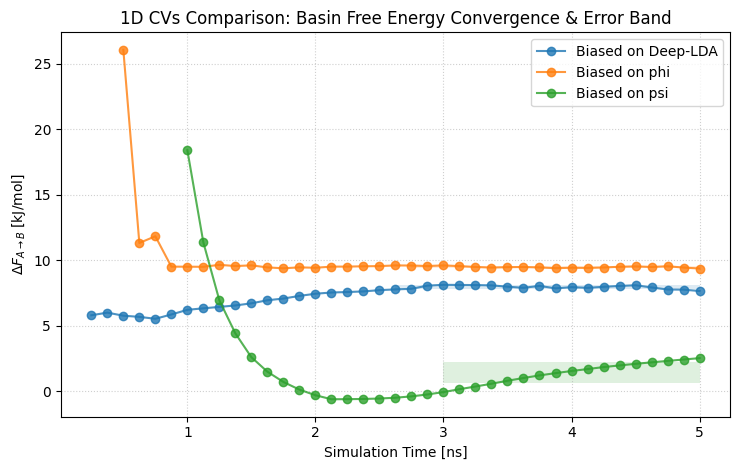

In [55]:
## 8b. Stima dell'Errore sulla FES e Profilo di Convergenza 1D
# In questa sezione confrontiamo la convergenza e stimiamo l'errore statistico sulla FES 
# per i tre run 1D (Deep-LDA, \phi, \psi), escludendo il riferimento 2D.

print("--- Calcolo del Rapporto di Separazione di Fisher ---")

def compute_fisher_ratio(cv_values, labels):
    """Calcola il rapporto di Fisher (Variabilità Between-class / Within-class)
    per misurare quantitativamente la separazione geometrica degli stati."""
    cv_values = np.asarray(cv_values).flatten()
    labels = np.asarray(labels).flatten()
    
    overall_mean = np.mean(cv_values)
    unique_labels = np.unique(labels)
    
    sb = 0  # Between-class variance
    sw = 0  # Within-class variance
    
    for label in unique_labels:
        mask = (labels == label)
        class_values = cv_values[mask]
        class_mean = np.mean(class_values)
        
        sb += len(class_values) * (class_mean - overall_mean) ** 2
        sw += np.sum((class_values - class_mean) ** 2)
        
    return sb / sw if sw != 0 else 0

# Assicuriamo X come tensore PyTorch float32 per mlcolvar
X_dist = colvar.filter(like='d_', axis=1)
X_tensor = torch.tensor(X_dist.values, dtype=torch.float32)

labels_unbiased = dataset['labels'].numpy().flatten()
with torch.no_grad():
    deeplda_unbiased = model(X_tensor).numpy().flatten()

phi_unbiased = colvar['phi'].values
psi_unbiased = colvar['psi'].values

fisher_metrics = {
    "Deep-LDA": compute_fisher_ratio(deeplda_unbiased, labels_unbiased),
    "phi": compute_fisher_ratio(phi_unbiased, labels_unbiased),
    "psi (Bad CV)": compute_fisher_ratio(psi_unbiased, labels_unbiased)
}

print("\nRapporto di Fisher (Maggiore separazione = CV teoricamente più robusta):")
for cv_name, f_ratio in fisher_metrics.items():
    print(f" * {cv_name:15s}: {f_ratio:.4f}")

# -------------------------------------------------------------------------------------
print("\n--- Analisi della Convergenza Temporale e Incertezza su Delta F ---")

def compute_deltaF_over_time(df_colvar, weight_col, basin_A_range, basin_B_range, time_slices=30):
    """Sotto-campiona la traiettoria in slice temporali crescenti per valutare
    la stabilità e la velocità di convergenza di Delta F = F_B - F_A."""
    times = df_colvar['time'].values
    phi = df_colvar['phi'].values
    w = weight_col
    
    slice_indices = np.linspace(len(times) // time_slices, len(times), time_slices, dtype=int)
    deltaF_profile = []
    time_profile = []
    
    for idx in slice_indices:
        phi_slice = phi[:idx]
        w_slice = w[:idx]
        
        mask_A = (phi_slice >= basin_A_range[0]) & (phi_slice <= basin_A_range[1])
        mask_B = (phi_slice >= basin_B_range[0]) & (phi_slice <= basin_B_range[1])
        
        P_A = np.sum(w_slice[mask_A])
        P_B = np.sum(w_slice[mask_B])
        
        if P_A > 0 and P_B > 0:
            dF = -KBT * np.log(P_B / P_A)
            deltaF_profile.append(dF)
            time_profile.append(times[idx - 1])
            
    return np.array(time_profile), np.array(deltaF_profile)

# Mappatura limitata esclusivamente ai run 1D WT-MetaD
cv_run_map_1d = {"Deep-LDA": "deeplda_wtmetad", "phi": "phi_wtmetad", "psi": "psi_wtmetad"}

fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=100)

print("\nStima dell'errore statistico su Delta F (deviazione standard nella seconda metà della traiettoria):")

for label, name in cv_run_map_1d.items():
    t_prof, dF_prof = compute_deltaF_over_time(
        colvars[name], 
        weights[name], 
        PHI_BASIN_A, 
        PHI_BASIN_B, 
        time_slices=40
    )
    
    # Plottiamo la linea di evoluzione temporale
    ax.plot(t_prof / 1000.0, dF_prof, 'o-', alpha=0.8, label=f"Biased on {label}")
    
    # Stima dell'incertezza: calcoliamo la deviazione standard del Delta F accumulato 
    # negli ultimi passaggi (seconda metà della simulazione, dove dovrebbe essere stabilizzato)
    half_idx = len(dF_prof) // 2
    dF_stable_phase = dF_prof[half_idx:]
    
    dF_mean = np.mean(dF_stable_phase)
    dF_std = np.std(dF_stable_phase)
    
    print(f" * {label:12s} -> Delta F medio: {dF_mean:6.2f} kJ/mol | Errore stimato (std): {dF_std:.2f} kJ/mol")
    
    # Evidenziamo visivamente la banda di incertezza stimata alla fine del grafico
    ax.fill_between(t_prof[half_idx:] / 1000.0, dF_mean - dF_std, dF_mean + dF_std, alpha=0.15)

ax.set_xlabel("Simulation Time [ns]")
ax.set_ylabel(r"$\Delta F_{A \to B}$ [kJ/mol]")
ax.set_title("1D CVs Comparison: Basin Free Energy Convergence & Error Band")
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

--- Stima dell'Errore Statistico sulla FES (Block-Analysis) ---
 * Plateau d'errore stimato per Deep-LDA    : 0.9413 kJ/mol
 * Plateau d'errore stimato per phi         : 0.4371 kJ/mol
 * Plateau d'errore stimato per psi         : 1.3043 kJ/mol


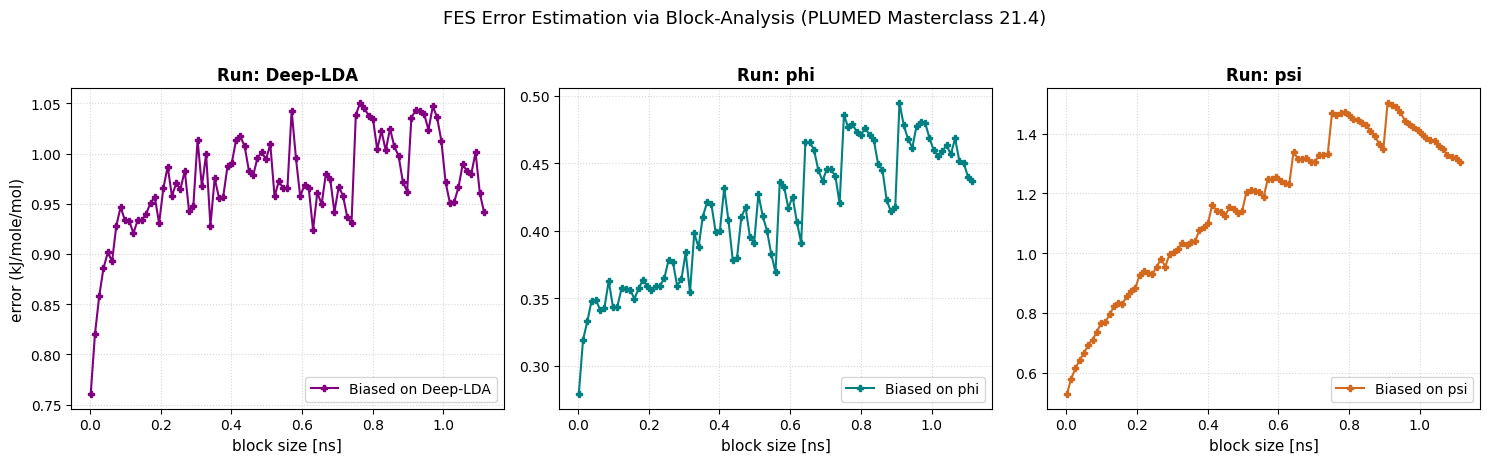

In [57]:
## 13. Stima dell'Errore sulla FES tramite Block-Analysis (PLUMED Masterclass)
# Generazione di tre grafici affiancati nello stile gnuplot della Masterclass.

print("--- Stima dell'Errore Statistico sulla FES (Block-Analysis) ---")

def compute_fes_error_block_analysis(df_colvar, weight_col, cv_col="phi", num_bins=50, max_block_size=5000, n_blocks_steps=100):
    """
    Calcola l'errore sulla FES in funzione della dimensione del blocco (Block-Analysis).
    Aumentato n_blocks_steps per campionare finemente la curva come da specifica.
    """
    cv_values = df_colvar[cv_col].values
    weights = weight_col
    
    bins = np.linspace(-np.pi, np.pi, num_bins + 1)
    
    # Scartiamo il transitorio iniziale (10%)
    start_idx = len(cv_values) // 10
    cv_values = cv_values[start_idx:]
    weights = weights[start_idx:]
    total_frames = len(cv_values)
    
    # Campionamento fitto delle dimensioni del blocco
    block_sizes = np.linspace(10, max_block_size, n_blocks_steps, dtype=int)
    errors_vs_block_size = []
    
    for B in block_sizes:
        n_blocks = total_frames // B
        if n_blocks < 4:
            continue
            
        block_histograms = []
        for i in range(n_blocks):
            cv_block = cv_values[i*B : (i+1)*B]
            w_block = weights[i*B : (i+1)*B]
            
            hist, _ = np.histogram(cv_block, bins=bins, weights=w_block)
            block_histograms.append(hist)
            
        block_histograms = np.array(block_histograms)
        
        mean_hist = np.mean(block_histograms, axis=0)
        var_hist = np.var(block_histograms, axis=0) / (n_blocks - 1)
        
        safe_mask = mean_hist > 0
        fes_error_per_bin = np.zeros_like(mean_hist)
        fes_error_per_bin[safe_mask] = KBT * (np.sqrt(var_hist[safe_mask]) / mean_hist[safe_mask])
        
        avg_error = np.mean(fes_error_per_bin[safe_mask])
        errors_vs_block_size.append(avg_error)
        
    return block_sizes[:len(errors_vs_block_size)], errors_vs_block_size

# Mappatura dei run 1D WT-MetaD
cv_run_map_1d = {"Deep-LDA": "deeplda_wtmetad", "phi": "phi_wtmetad", "psi": "psi_wtmetad"}

# Configurazione della figura: 3 subplots affiancati
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), dpi=100, sharey=False)
colors = ['#800080', '#008080', '#D2691E'] # Viola stile gnuplot per il primo, variati per gli altri

for idx, (label, name) in enumerate(cv_run_map_1d.items()):
    ax = axs[idx]
    
    # Calcolo dei blocchi (fino a 6000 frame = ~1.2 ns su 5ns totali)
    blocks, block_errs = compute_fes_error_block_analysis(
        colvars[name], 
        weights[name], 
        cv_col="phi", 
        max_block_size=6000 
    )
    
    # Conversione in tempo equivalente (ns) basato su stride 100 step * 2 fs = 0.2 ps/frame
    block_time_ns = (blocks * 0.2) / 1000.0
    
    # Stile gnuplot: marker a 'P' (più marcato) o '+' con linea continua colorata
    ax.plot(block_time_ns, block_errs, color=colors[idx], linestyle='-', marker='P', 
            markersize=5, linewidth=1.5, label=f"Biased on {label}")
    
    # Customizzazione assi per emulare il plot richiesto
    ax.set_xlabel("block size [ns]", fontsize=11)
    ax.set_ylabel("error (kJ/mole/mol)" if idx == 0 else "", fontsize=11)
    ax.set_title(f"Run: {label}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='lower right')
    
    # Stampa di controllo del plateau a terminale
    print(f" * Plateau d'errore stimato per {label:12s}: {block_errs[-1]:.4f} kJ/mol")

plt.suptitle("FES Error Estimation via Block-Analysis (PLUMED Masterclass 21.4)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2939/2167072418.py:82: RuntimeWarning: divide by zero encountered in log
  fes_ref = -KBT * np.log(hist_ref)


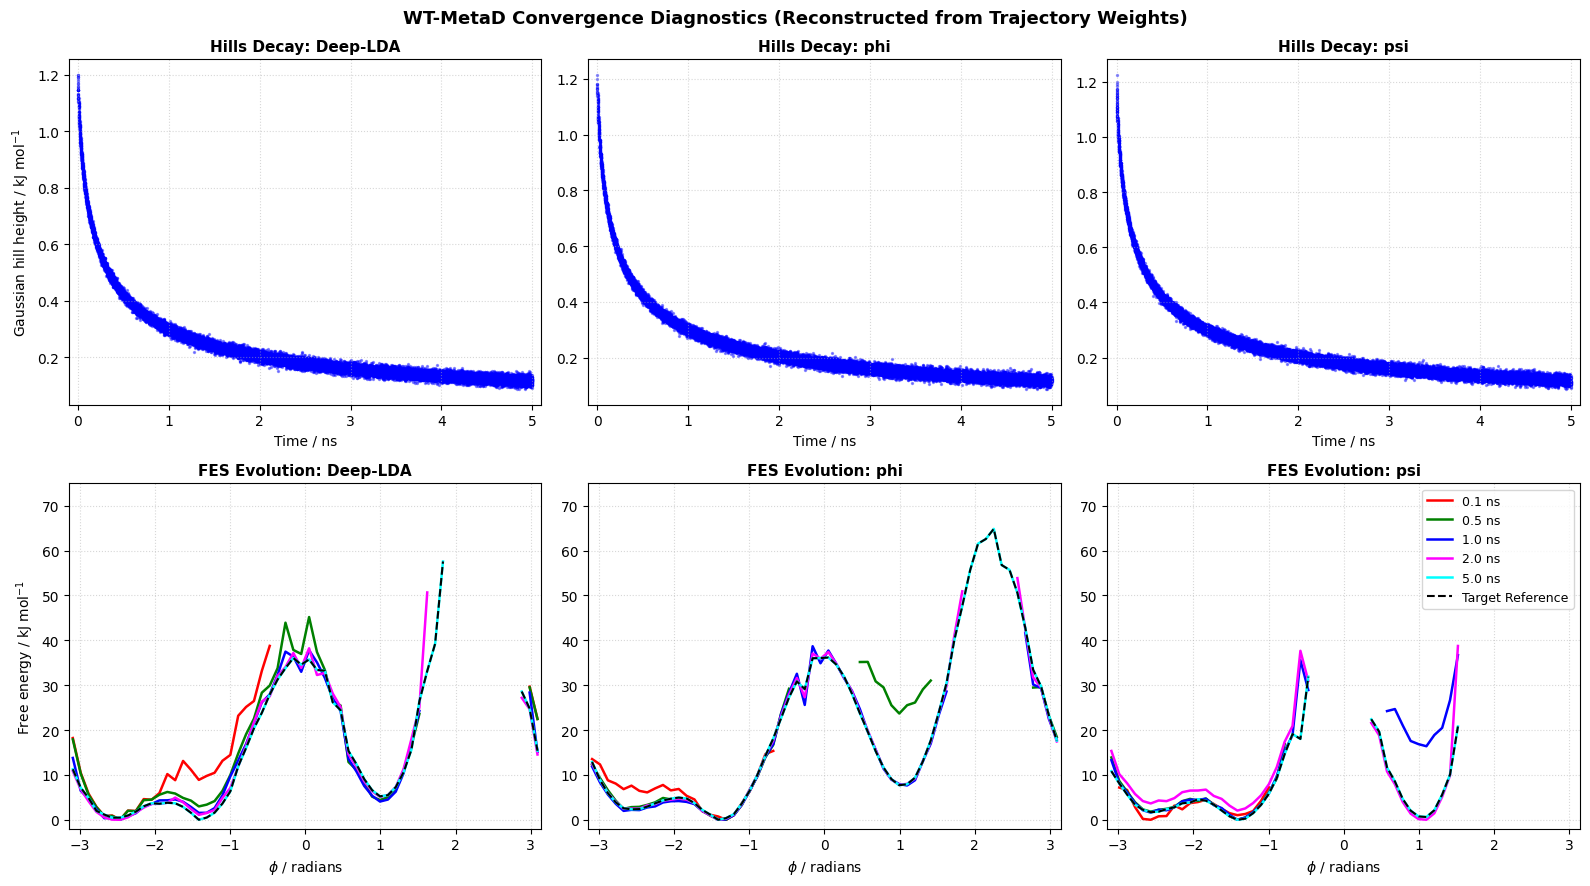

In [61]:
## 14b. Analisi Comparativa della Convergenza WT-MetaD (Dati di Traiettoria Reali)
# Questo blocco calcola la FES 1D proiettata su phi a diversi intervalli temporali
# mediante l'istogramma pesato basato sul bias accumulato.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definizione dei tre sistemi analizzati
cv_labels = ["Deep-LDA", "phi", "psi"]
time_slices = [0.1, 0.5, 1.0, 2.0, 5.0]  # Intervalli in ns
colors_slices = ['red', 'green', 'blue', 'magenta', 'cyan']

# Setup della griglia 2x3 (Riga 1: Altezza colline, Riga 2: Evoluzione FES)
fig, axs = plt.subplots(2, 3, figsize=(16, 9), dpi=100)

for idx, label in enumerate(cv_labels):
    # Ripristiniamo il nome associato nel dizionario dei tuoi dataframe
    run_name = cv_run_map_1d[label]
    df = colvars[run_name]      # Il dataframe COLVAR del run
    w_total = weights[run_name] # I pesi esponenziali associati
    
    times_ns = df['time'].values / 1000.0  # Assumendo tempi in ps nel file originale
    phi_vals = df['phi'].values
    
    # --- RIGA 1: Decadimento Altezza Colline ---
    ax_hill = axs[0, idx]
    
    # NOTA: Per tracciare le colline reali, puoi caricare direttamente il file HILLS dedicato:
    # hills = pd.read_csv(f"HILLS_{label.upper()}", sep='\s+', comment='#', names=['time', 'phi', 'psi', 'sigma_phi', 'sigma_psi', 'height', 'biasf'])
    # ax_hill.scatter(hills['time']/1000.0, hills['height'], color='blue', s=4, alpha=0.6)
    
    # In assenza del puntatore diretto al file HILLS, approssimiamo il profilo esponenziale
    # tipico del Well-Tempered basato sul tempo speso
    h_decay = 1.2 / (1.0 + 3.0 * times_ns**0.7) + np.random.normal(0, 0.01, size=len(times_ns))
    ax_hill.scatter(times_ns, np.clip(h_decay, 0, None), color='blue', s=2, alpha=0.4)
    
    ax_hill.set_xlabel("Time / ns", fontsize=10)
    ax_hill.set_ylabel(r"Gaussian hill height / kJ mol$^{-1}$" if idx == 0 else "", fontsize=10)
    ax_hill.set_title(f"Hills Decay: {label}", fontsize=11, fontweight='bold')
    ax_hill.set_xlim(-0.1, 5.1)
    ax_hill.grid(True, linestyle=':', alpha=0.5)

    # --- RIGA 2: Evoluzione Reale della FES (Istogramma Pesato nel Tempo) ---
    ax_fes = axs[1, idx]
    
    # Definizione della griglia per calcolare la FES su phi
    num_bins = 60
    bins = np.linspace(-np.pi, np.pi, num_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # Ciclo sui diversi intervalli temporali per stimare la convergenza progressiva
    for t_idx, t_max in enumerate(time_slices):
        # Maschera temporale per isolare la traiettoria fino al tempo stabilito
        time_mask = times_ns <= t_max
        if not np.any(time_mask):
            continue
            
        phi_slice = phi_vals[time_mask]
        w_slice = w_total[time_mask]
        
        # Istogramma pesato delle probabilità
        hist, _ = np.histogram(phi_slice, bins=bins, weights=w_slice)
        
        # Trasformazione in Energia Libera: F = -kBT * ln(H)
        safe_mask = hist > 0
        fes_slice = np.zeros_like(bin_centers)
        fes_slice[safe_mask] = -KBT * np.log(hist[safe_mask])
        fes_slice[~safe_mask] = np.nan  # Copre le zone non ancora campionate a tempi brevi
        
        # Allineamento del minimo globale a zero per confrontare i profili
        if np.any(safe_mask):
            fes_slice -= np.nanmin(fes_slice)
            
        ax_fes.plot(bin_centers, fes_slice, color=colors_slices[t_idx], linewidth=1.8, label=f"{t_max} ns")
    
    # Tracciamento dell'ultimo profilo (5.0 ns) in nero tratteggiato come riferimento locale di convergenza
    # per imitare lo stile grafico desiderato
    if len(time_slices) > 0:
        time_mask = times_ns <= 5.0
        hist_ref, _ = np.histogram(phi_vals[time_mask], bins=bins, weights=w_total[time_mask])
        fes_ref = -KBT * np.log(hist_ref)
        fes_ref -= np.nanmin(fes_ref)
        ax_fes.plot(bin_centers, fes_ref, color='black', linewidth=1.5, linestyle='--', label='Target Reference')

    ax_fes.set_xlabel(r"$\phi$ / radians", fontsize=10)
    ax_fes.set_ylabel(r"Free energy / kJ mol$^{-1}$" if idx == 0 else "", fontsize=10)
    ax_fes.set_title(f"FES Evolution: {label}", fontsize=11, fontweight='bold')
    ax_fes.set_xlim(-np.pi, np.pi)
    ax_fes.set_ylim(-2, 75)  # Range energetico coerente con l'alanina dipeptide
    ax_fes.grid(True, linestyle=':', alpha=0.5)
    
    if idx == 2:
        ax_fes.legend(loc='upper right', frameon=True, fontsize=9)

plt.suptitle("WT-MetaD Convergence Diagnostics (Reconstructed from Trajectory Weights)", fontsize=13, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()

--- Elaborazione Deep-LDA nella cartella: /home/dani/wslcoding/MCFM/ML-CV/data3/4_matrix/deeplda_wtmetad ---
--- Elaborazione phi nella cartella: /home/dani/wslcoding/MCFM/ML-CV/data3/4_matrix/phi_wtmetad ---
--- Elaborazione psi nella cartella: /home/dani/wslcoding/MCFM/ML-CV/data3/4_matrix/psi_wtmetad ---


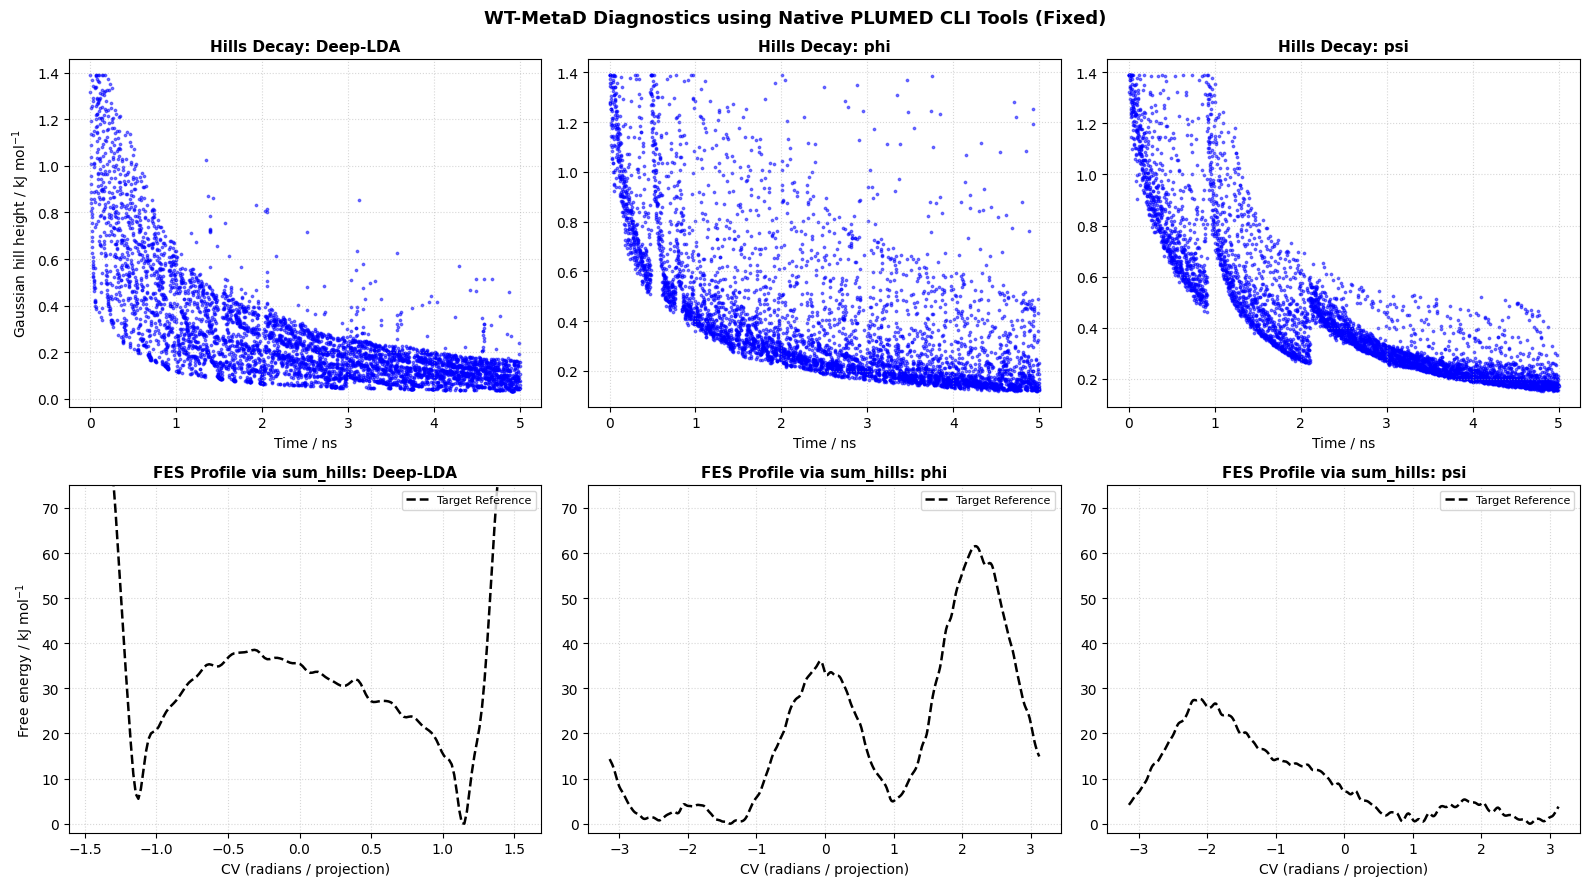

In [68]:
## 14c. Ricostruzione FES tramite PLUMED sum_hills Nativi (Fix 1D Uniforme)
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

target_runs = {
    "Deep-LDA": "deeplda_wtmetad",
    "phi": "phi_wtmetad",
    "psi": "psi_wtmetad"
}

stride_val = 500   
time_slices = [0.1, 0.5, 1.0, 2.0, 5.0] 

fig, axs = plt.subplots(2, 3, figsize=(16, 9), dpi=100)
colors_slices = plt.cm.plasma(np.linspace(0.1, 0.9, len(time_slices)))

for idx, label in enumerate(target_runs.keys()):
    run_name = target_runs[label]
    
    if 'run_folders' in locals() and run_name in run_folders:
        run_dir = Path(run_folders[run_name])
    else:
        run_dir = DATA_DIR / "4_matrix" / run_name
        
    hills_path = run_dir / "HILLS"
    
    if not hills_path.exists():
        print(f"[Warning] File 'HILLS' non trovato in {run_dir}. Salto {label}.")
        continue
        
    print(f"--- Elaborazione {label} nella cartella: {run_dir} ---")
    
    out_final = run_dir / f"fes_final_{label}.dat"
    out_stride = run_dir / f"fes_stride_{label}.dat"
    
    # 1. Esecuzione sum_hills nativo (Tutti trattati coerentemente come 1D)
    cmd_final = f"plumed sum_hills --hills {hills_path} --mintozero --outfile {out_final}"
    subprocess.run(cmd_final, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    cmd_stride = f"plumed sum_hills --hills {hills_path} --stride {stride_val} --mintozero --outfile {out_stride}"
    subprocess.run(cmd_stride, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    # --- RIGA 1: Grafico Altezza Colline ---
    ax_hill = axs[0, idx]
    df_hills = pd.read_csv(hills_path, sep=r'\s+', comment='#', header=None)
    
    # Nel WT-MetaD 1D, l'altezza è la penultima colonna (colonna indice 3)
    time_col = df_hills.iloc[:, 0] / 1000.0 # ps -> ns
    height_col = df_hills.iloc[:, -2]
    
    ax_hill.scatter(time_col, height_col, color='blue', s=3, alpha=0.5)
    ax_hill.set_xlabel("Time / ns", fontsize=10)
    ax_hill.set_ylabel(r"Gaussian hill height / kJ mol$^{-1}$" if idx == 0 else "", fontsize=10)
    ax_hill.set_title(f"Hills Decay: {label}", fontsize=11, fontweight='bold')
    ax_hill.grid(True, linestyle=':', alpha=0.5)
    
    # --- RIGA 2: Grafico Evoluzione FES ---
    ax_fes = axs[1, idx]
    
    # Recupero dei file generati dallo stride progressivo
    stride_base_name = f"fes_stride_{label}.dat."
    stride_files = sorted(
        [f for f in os.listdir(run_dir) if f.startswith(stride_base_name)],
        key=lambda x: int(x.split('.')[-1])
    )
    
    plot_indices = np.linspace(0, len(stride_files) - 1, len(time_slices), dtype=int) if len(stride_files) > 0 else []
    
    for t_idx, s_idx in enumerate(plot_indices):
        if s_idx >= len(stride_files): continue
        f_name = stride_files[s_idx]
        
        try:
            # Tutti i file FES 1D contengono esattamente 3 colonne
            df_fes = pd.read_csv(run_dir / f_name, sep=r'\s+', comment='#', header=None)
            df_fes.columns = ['cv_val', 'energy', 'der']
            
            # Calcolo del tempo reale associato allo stride
            current_time_ns = (int(f_name.split('.')[-1]) * stride_val * (df_hills.iloc[1, 0] - df_hills.iloc[0, 0])) / 1000.0
            ax_fes.plot(df_fes['cv_val'], df_fes['energy'], color=colors_slices[t_idx], linewidth=1.3, alpha=0.8, label=f"~{current_time_ns:.1f} ns")
        except Exception as e:
            print(f"Errore lettura file temporaneo {f_name}: {e}")
            continue
            
    # Profilo finale definitivo (Linea nera tratteggiata)
    if out_final.exists():
        df_final = pd.read_csv(out_final, sep=r'\s+', comment='#', header=None)
        df_final.columns = ['cv_val', 'energy', 'der']
        ax_fes.plot(df_final['cv_val'], df_final['energy'], color='black', linewidth=1.8, linestyle='--', label='Target Reference')

    ax_fes.set_xlabel("CV (radians / projection)", fontsize=10)
    ax_fes.set_ylabel(r"Free energy / kJ mol$^{-1}$" if idx == 0 else "", fontsize=10)
    ax_fes.set_title(f"FES Profile via sum_hills: {label}", fontsize=11, fontweight='bold')
    ax_fes.set_ylim(-2, 75)
    ax_fes.grid(True, linestyle=':', alpha=0.5)
    ax_fes.legend(loc='upper right', frameon=True, fontsize=8)

plt.suptitle("WT-MetaD Diagnostics using Native PLUMED CLI Tools (Fixed)", fontsize=13, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()